# 4. Análise Exploratória dos Dados


In [9]:
# Importando dependências para AED
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from matplotlib.ticker import MultipleLocator
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

In [10]:
# Lendo os dados extraídos e pré-processados do ENEM
data_folder = "../data/final/cleaned_enem_data.csv"

enem_df = pd.read_csv(data_folder)
enem_df.head()

,numero_questao,enunciado,alternativas,gabarito,ano,gabarito_texto,distratores,enunciado_tokens,gabarito_tokens,distratores_tokens,dificuldade
0,1,A atmosfera terrestre é composta pelos gases n...,A: reduzir o calor irradiado pela Terra median...,C,2009,"reduzir o desmatamento, mantendo-se, assim, o ...",reduzir o calor irradiado pela Terra mediante ...,atmosfera terrestre composta gases nitrogênio ...,reduzir desmatamento mantendo assim potencial ...,reduzir calor irradiado terra mediante substit...,-1.70677
1,2,Analise a figura. Supondo que seja necessário ...,A: Concentração média de álcool no sangue ao l...,D,2009,Estimativa de tempo necessário para metaboliza...,Concentração média de álcool no sangue ao long...,analise figura supondo necessário dar título f...,estimativa tempo necessário metabolizar difere...,concentração média álcool sangue longo dia var...,0.62043
2,3,Estima-se que haja atualmente no mundo 40 milh...,"A: induzir a imunidade, para proteger o organi...",A,2009,"induzir a imunidade, para proteger o organismo...",ser capaz de alterar o genoma do organismo por...,estima atualmente mundo milhões pessoas infect...,induzir imunidade proteger organismo contamina...,capaz alterar genoma organismo portador induzi...,2.07704
3,4,"Em um experimento, preparou-se um conjunto de ...",A: os genótipos e os fenótipos idênticos.; B: ...,B,2009,os genótipos idênticos e os fenótipos diferentes.,os genótipos e os fenótipos idênticos.; difere...,experimento preparou conjunto plantas técnica ...,genótipos idênticos fenótipos diferentes,genótipos fenótipos idênticos diferenças genót...,0.11500
4,5,"Na linha de uma tradição antiga, o astrônomo g...",A: Ptolomeu apresentou as ideias mais valiosas...,E,2009,"Kepler apresentou uma teoria científica que, g...","Ptolomeu apresentou as ideias mais valiosas, p...",linha tradição antiga astrônomo grego ptolomeu...,kepler apresentou teoria científica graças mét...,ptolomeu apresentou ideias valiosas serem anti...,0.21694


---
## 4.1. Entendendo os Dados


### 4.1.1. Dicionário de Dados

- **Numero_questao** — Número identificador da questão na prova;

- **Enunciado** — Texto do enunciado da questão;
- **Alternativas** — String contendo todas as alternativas da questão em formato (A: ...; B: ...; C: ...; D: ...; E: ...);
- **Gabarito** — Letra da alternativa correta (A, B, C, D ou E);
- **Ano** — Ano de aplicação da prova correspondente à questão;
- **Gabarito_texto** — Texto completo da alternativa correta (não apenas a letra);
- **Distratores** — Lista contendo os textos das alternativas incorretas;
- **Enunciado_tokens** — Lista de tokens extraídos do enunciado após pré-processamento;
- **Gabarito_tokens** — Lista de tokens extraídos do texto da alternativa correta;
- **Distratores_tokens** — Lista de listas, contendo tokens de cada distrator individualmente;
- **Dificuldade** (*Target*) — Valor numérico indicando a dificuldade da questão (coletada dos microdados).


### 4.1.2. Estrutura


In [11]:
print(f"Número de linhas e colunas: {enem_df.shape}")

Número de linhas e colunas: (605, 11)


In [12]:
print(f"Tipos de dados: {enem_df.dtypes}")

Tipos de dados: numero_questao          int64
enunciado              object
alternativas           object
gabarito               object
ano                     int64
gabarito_texto         object
distratores            object
enunciado_tokens       object
gabarito_tokens        object
distratores_tokens     object
dificuldade           float64
dtype: object


### 4.1.3. Verificando Dados Ausentes/Duplicados


In [13]:
enem_df.isnull().sum()

numero_questao        0
enunciado             0
alternativas          0
gabarito              0
ano                   0
gabarito_texto        0
distratores           0
enunciado_tokens      0
gabarito_tokens       0
distratores_tokens    0
dificuldade           0
dtype: int64

In [14]:
enem_df.isna().sum()

numero_questao        0
enunciado             0
alternativas          0
gabarito              0
ano                   0
gabarito_texto        0
distratores           0
enunciado_tokens      0
gabarito_tokens       0
distratores_tokens    0
dificuldade           0
dtype: int64

In [15]:
enem_df.duplicated().sum()

0

### 4.1.4. Número de Questões Disponíveis por Ano

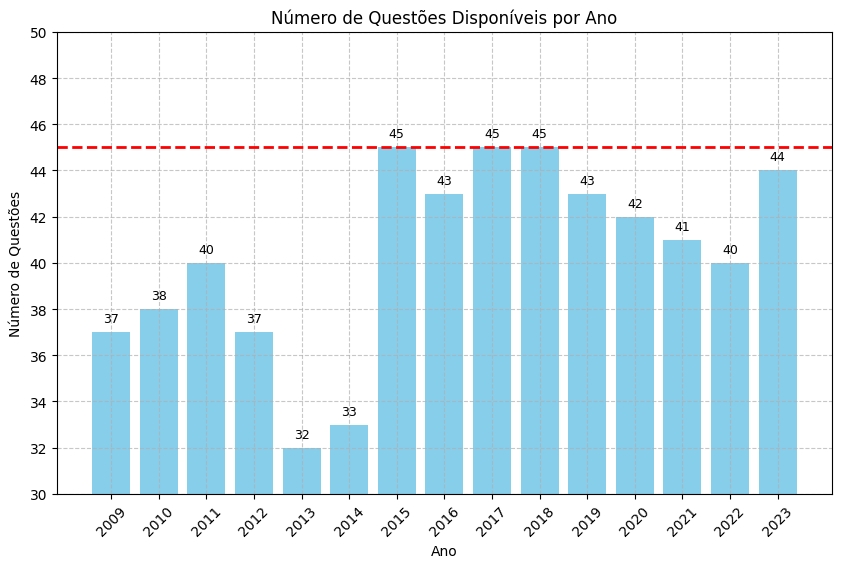

In [16]:
ano_counts = enem_df["ano"].value_counts().sort_index()
ano_counts_clipped = ano_counts.clip(upper=45)

fig, ax = plt.subplots(figsize=(10, 6))

# Gráfico de barras
bars = ax.bar(ano_counts.index, ano_counts.values, color="skyblue")

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),  # deslocamento vertical
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
    )

# Linha Horizontal com limite de questões por ano (45)
ax.axhline(y=45, color="red", linestyle="--", linewidth=2)

# Personalizando o gráfico
ax.set_title("Número de Questões Disponíveis por Ano")
ax.set_xlabel("Ano")
ax.set_ylabel("Número de Questões")
ax.set_xticks(ano_counts.index)
ax.set_xticklabels(ano_counts.index, rotation=45)
ax.grid(True, linestyle="--", alpha=0.7)
ax.set_ylim(30, 50)
ax.yaxis.set_major_locator(MultipleLocator(2))

# Exibindo
plt.show()

---

## 4.2. Análise do Parâmetro B (Dificuldade)

Nesta seção, analisamos a distribuição do **parâmetro B (dificuldade)** das questões, uma vez que essa é a variável **target** da tarefa preditiva.


### 4.2.1. Resumo Estatístico


In [17]:
enem_df["dificuldade"].describe()

count    605.000000
mean       1.347886
std        0.903377
min       -1.800920
25%        0.792130
50%        1.385420
75%        1.858780
max        8.961860
Name: dificuldade, dtype: float64

### 4.2.2. Distribuição


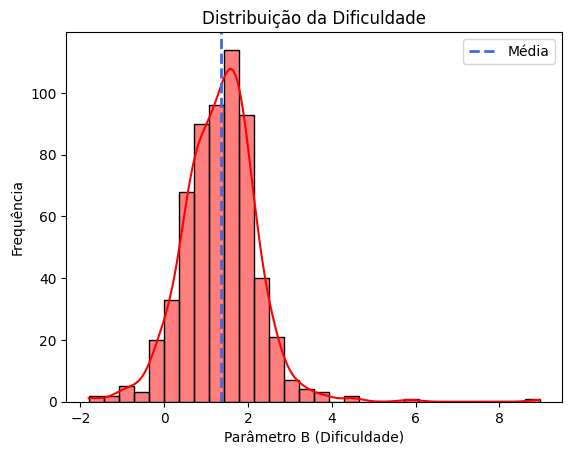

In [18]:
sns.histplot(enem_df["dificuldade"], bins=30, kde=True, color="red")
plt.axvline(
    enem_df["dificuldade"].mean(),
    color="royalblue",
    linestyle="--",
    linewidth=2,
    label="Média",
)
plt.title("Distribuição da Dificuldade")
plt.xlabel("Parâmetro B (Dificuldade)")
plt.ylabel("Frequência")
plt.legend()

### 4.2.3. Q-Q Plot


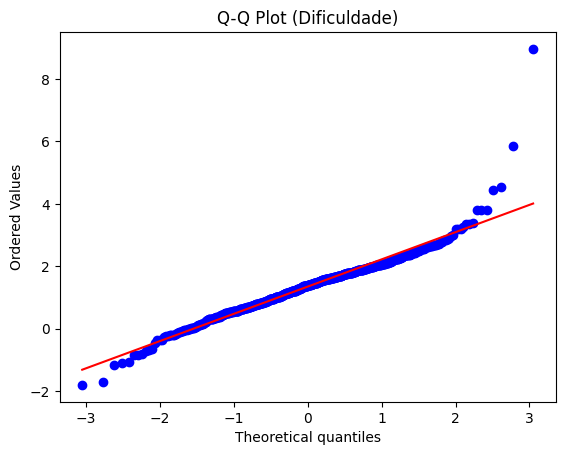

In [19]:
# Gerando gráfico Q-Q Plot da Dificuldade
stats.probplot(enem_df["dificuldade"], dist="norm", plot=plt)

plt.title("Q-Q Plot (Dificuldade)")
plt.show()

### 4.2.4. Teste de Normalidade Shapiro-Wilk

**Hipóteses:**

- H₀: Os dados seguem uma distribuição normal.
- H₁: Os dados não seguem uma distribuição normal.


In [20]:
stat, p_value = stats.shapiro(enem_df["dificuldade"])
print(f"Estatística de teste: {stat}")
print(f"p-valor: {p_value}")

if p_value > 0.05:
    print("Não rejeita H_0: Dados seguem distribuição normal.")
else:
    print("Rejeita H_0: Dados não seguem distribuição normal.")

Estatística de teste: 0.9319401131534603
p-valor: 5.854356505237993e-16
Rejeita H_0: Dados não seguem distribuição normal.


### 4.2.5. Aplicando Filtro entre -3,0 e 3,0 (Sugestão do Artigo)


In [21]:
def maximo_sem_outlier(group):
    Q1 = group.quantile(0.25)
    Q3 = group.quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    return group[group <= limite_superior].max()


maximo_por_ano = enem_df.groupby("ano")["dificuldade"].apply(maximo_sem_outlier)
maximo_por_ano

ano
2009    3.35507
2010    2.22673
2011    3.19792
2012    2.54600
2013    3.38570
2014    2.85490
2015    2.67280
2016    2.65321
2017    2.91532
2018    2.55861
2019    3.36471
2020    2.72331
2021    2.36189
2022    2.76588
2023    2.35841
Name: dificuldade, dtype: float64

O corte de dificuldade 3, feito no artigo, não parece de todo arbitrário.

Afinal, na maioria dos anos, o máximo de dificuldade (excluídos os outliers) não ultrapassa 3 frequentemente. Como sugestão, possível utilizar o corte do máximo da lista (ano de 2013, com 3.38570)


In [22]:
enem_df_filtered = enem_df[
    (enem_df["dificuldade"] >= -3) & (enem_df["dificuldade"] <= 3)
]
enem_df_filtered["dificuldade"].describe()

count    591.000000
mean       1.281414
std        0.768053
min       -1.800920
25%        0.777885
50%        1.372000
75%        1.819295
max        2.992980
Name: dificuldade, dtype: float64

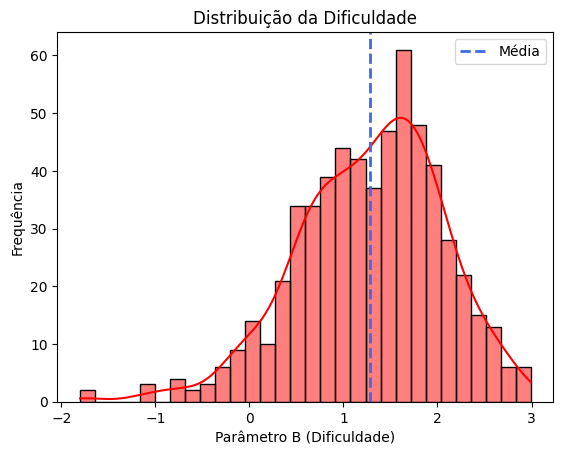

In [23]:
# Distribuição da Dificuldade após filtragem
sns.histplot(enem_df_filtered["dificuldade"], bins=30, kde=True, color="red")
plt.axvline(
    enem_df_filtered["dificuldade"].mean(),
    color="royalblue",
    linestyle="--",
    linewidth=2,
    label="Média",
)
plt.title("Distribuição da Dificuldade")
plt.xlabel("Parâmetro B (Dificuldade)")
plt.ylabel("Frequência")
plt.legend()

In [24]:
stat, p_value = stats.shapiro(enem_df_filtered["dificuldade"])
print(f"Estatística de teste: {stat}")
print(f"p-valor: {p_value}")

if p_value > 0.05:
    print("Não rejeita H_0: Dados seguem distribuição normal.")
else:
    print("Rejeita H_0: Dados não seguem distribuição normal.")

Estatística de teste: 0.9839477530006064
p-valor: 4.302020663439456e-06
Rejeita H_0: Dados não seguem distribuição normal.


**Resultados:**

- **Estatística de teste:** 0.9841
- **p-valor:** 0.00000

**Decisão:**  
Rejeita-se a hipótese nula (H₀).

**Conclusão:**

- Os dados **não seguem** uma distribuição normal, com nível de significância de 5%.
- Com a exclusão da hipótese de normalidade, é preciso se atentar se o modelo de predição possui sensibilidade à distribuição.
- Caso seja possível, aplicar transformação Box-Cox.


### 4.2.6. Boxplot Dificuldade por Ano


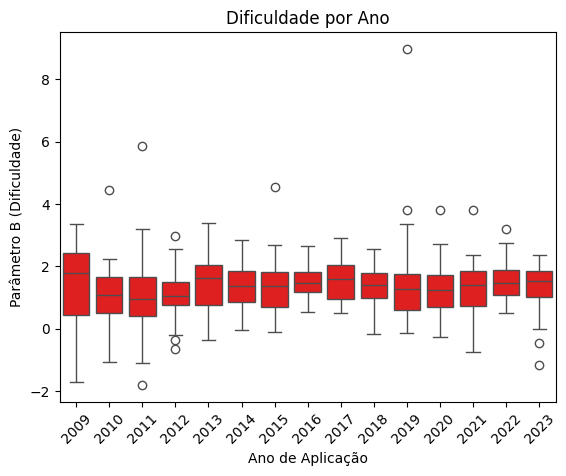

In [25]:
sns.boxplot(
    x="ano",
    y="dificuldade",
    data=enem_df,
    order=sorted(enem_df["ano"].unique()),
    color="red",
)
plt.xlabel("Ano de Aplicação")
plt.ylabel("Parâmetro B (Dificuldade)")
plt.title("Dificuldade por Ano")
plt.xticks(rotation=45)

plt.show()

### 4.2.7. Item com Maior Parâmetro de Dificuldade

In [26]:
item_maior_dificuldade = enem_df.loc[enem_df["dificuldade"].idxmax()]

print(f"Enunciado: {item_maior_dificuldade['enunciado']}")
print(f"Alternativas: {item_maior_dificuldade['alternativas']}")
print(f"Gabarito: {item_maior_dificuldade['gabarito_texto']}")
print(f"Ano: {item_maior_dificuldade['ano']}")
print(f"Dificuldade: {item_maior_dificuldade['dificuldade']:.5f}")

Enunciado: Grupos de pesquisa em todo o mundo vêm buscando 
soluções inovadoras, visando a produção de dispositivos 
para a geração de energia elétrica. Dentre eles,  
pode-se destacar as baterias de zinco-ar, que combinam 
o oxigênio atmosférico e o metal zinco em um eletrólito 
aquoso de caráter alcalino. O esquema de funcionamento 
da bateria zinco-ar está apresentado na figura.
Descrição da figura:
A figura apresenta uma célula eletroquímica 
formada por duas semicélulas separadas por uma 
membrana separadora.; A semicélula da esquerda contém um eletrodo 
poroso. Moléculas do gás oxigênio atravessam 
esse eletrodo e se transformam no íon OH de 
carga negativa. Há um fluxo de íons OH de carga 
negativa que atravessam a membrana separadora 
indo até a semicélula da direita, que contém um 
eletrodo de zinco, onde é formado o Zn(OH)4
 de 
carga 2−. Essa célula eletroquímica está ligada a 
uma lâmpada através de dois fios: um que parte do 
eletrodo poroso e outro que parte do eletrodo d

### 4.2.8. Item com Menor Parâmetro de Dificuldade

In [28]:
item_menor_dificuldade = enem_df.loc[enem_df["dificuldade"].idxmin()]

print(f"Enunciado: {item_menor_dificuldade['enunciado']}")
print(f"Alternativas: {item_menor_dificuldade['alternativas']}")
print(f"Gabarito: {item_menor_dificuldade['gabarito_texto']}")
print(f"Ano: {item_menor_dificuldade['ano']}")
print(f"Dificuldade: {item_menor_dificuldade['dificuldade']:.5f}")

Enunciado: Certas espécies de algas são capazes de absorver rapidamente compostos inorgânicos presentes na água, acumulando-os durante seu crescimento. Essa capacidade fez com que se pensasse em usá-las como biofiltros para a limpeza de ambientes aquáticos contaminados, removendo, por exemplo, nitrogênio e fósforo de resíduos orgânicos e metais pesados provenientes de rejeitos industriais lançados nas águas. Na técnica do cultivo integrado, animais e algas crescem de forma associada, promovendo um maior equilíbrio ecológico. A utilização da técnica do cultivo integrado de animais e algas representa uma proposta favorável a um ecossistema mais equilibrado porque
Alternativas: A: os animais eliminam metais pesados, que são usados pelas algas para a síntese de biomassa.; B: os animais fornecem excretas orgânicos nitrogenados, que são transformados em gás carbônico pelas algas.; C: as algas usam os resíduos nitrogenados liberados pelos animais e eliminam gás carbônico na fotossíntese, usad

---

## 4.3. Análise dos Enunciados


### 4.3.1. Distribuição


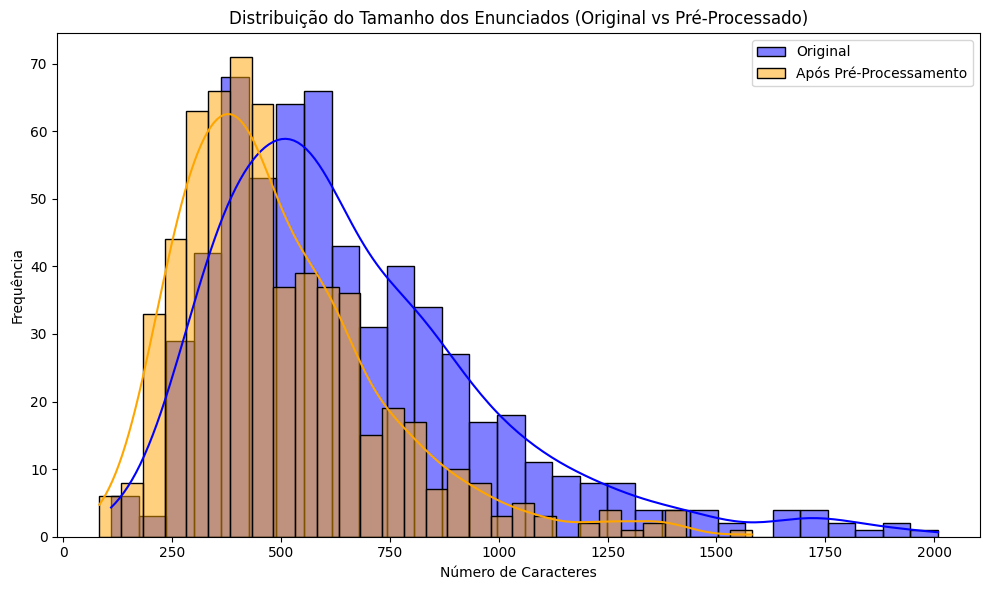

In [30]:
plt.figure(figsize=(10, 6))

# Coletando tamanho dos enunciados
tamanho_enunciados = enem_df["enunciado"].str.len()
tamanho_enunciados_tokens = enem_df["enunciado_tokens"].str.len()

# Histograma dos enunciados originais
sns.histplot(
    tamanho_enunciados, bins=30, kde=True, color="blue", label="Original", alpha=0.5
)

# Histograma dos enunciados pré-processados
sns.histplot(
    tamanho_enunciados_tokens,
    bins=30,
    kde=True,
    color="orange",
    label="Após Pré-Processamento",
    alpha=0.5,
)

plt.title("Distribuição do Tamanho dos Enunciados (Original vs Pré-Processado)")
plt.xlabel("Número de Caracteres")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()

### 4.3.2. Gráfico de Dispersão (Dificuldade)


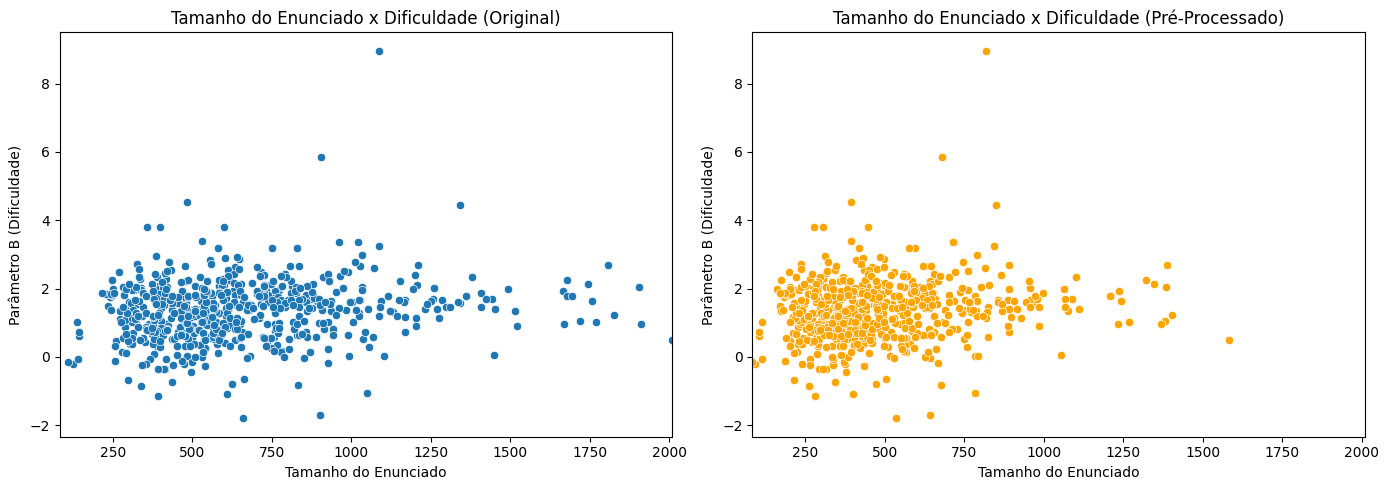

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de dispersão do tamanho dos enunciados
sns.scatterplot(x=tamanho_enunciados, y=enem_df["dificuldade"], ax=axes[0])
axes[0].set_title("Tamanho do Enunciado x Dificuldade (Original)")
axes[0].set_ylabel("Parâmetro B (Dificuldade)")
axes[0].set_xlabel("Tamanho do Enunciado")

# Gráfico de dispersão do tamanho dos enunciados pré-processados
sns.scatterplot(
    x=tamanho_enunciados_tokens, y=enem_df["dificuldade"], ax=axes[1], color="orange"
)
axes[1].set_title("Tamanho do Enunciado x Dificuldade (Pré-Processado)")
axes[1].set_ylabel("Parâmetro B (Dificuldade)")
axes[1].set_xlabel("Tamanho do Enunciado")

x_min = tamanho_enunciados_tokens.min()
x_max = tamanho_enunciados.max()
axes[0].set_xlim(x_min, x_max)
axes[1].set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

Não se verifica um correlação direta entre o tamanho do enunciado e a dificuldade da questão, muito embora se verifique uma pequena concentração entre 0 e 2 nos menores enunciados.


---

## 4.4. Análise das Alternativas


### 4.4.1. Distribuição das Alternativas Corretas (Gabarito)


Text(0, 0.5, 'Frequência')

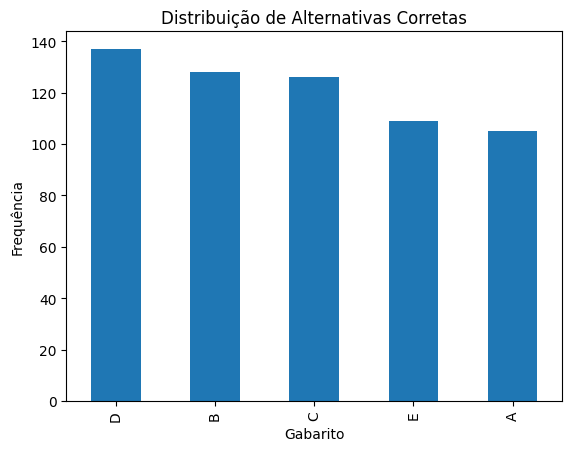

In [32]:
ax = (
    enem_df["gabarito"]
    .value_counts()
    .plot(kind="bar", title="Distribuição de Alternativas Corretas")
)
ax.set_xlabel("Gabarito")
ax.set_ylabel("Frequência")

### 4.4.2. Distribuição do Tamanho do Gabarito


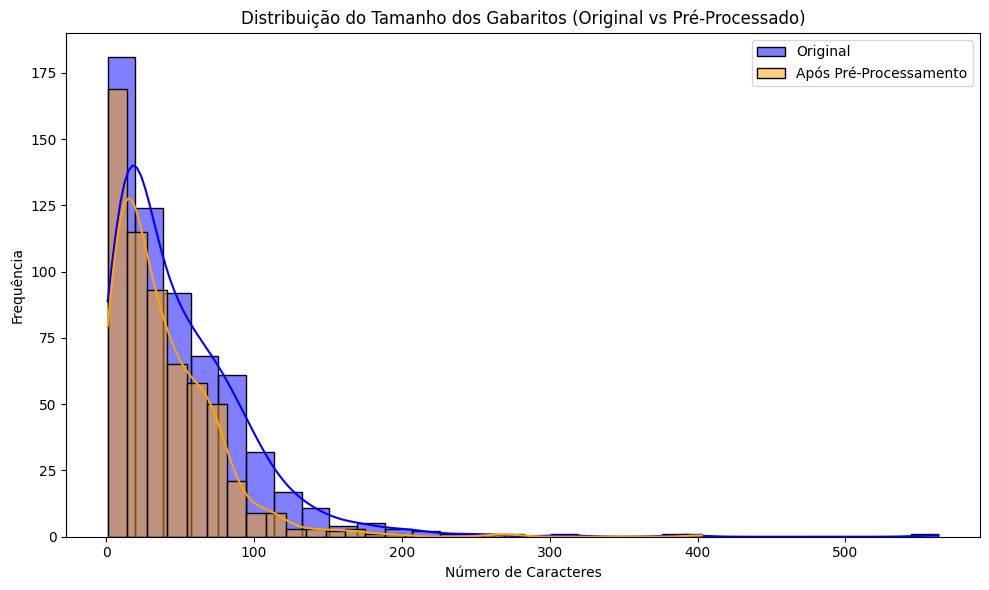

In [33]:
plt.figure(figsize=(10, 6))

# Coletando tamanho dos gabaritos
tamanho_gabarito = enem_df["gabarito_texto"].str.len()
tamanho_gabarito_tokens = enem_df["gabarito_tokens"].str.len()

# Histograma dos gabaritos originais
sns.histplot(
    tamanho_gabarito, bins=30, kde=True, color="blue", label="Original", alpha=0.5
)

# Histograma dos gabaritos pré-processados
sns.histplot(
    tamanho_gabarito_tokens,
    bins=30,
    kde=True,
    color="orange",
    label="Após Pré-Processamento",
    alpha=0.5,
)

plt.title("Distribuição do Tamanho dos Gabaritos (Original vs Pré-Processado)")
plt.xlabel("Número de Caracteres")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()

### 4.4.3. Gráfico de Dispersão (Gabarito x Dificuldade)


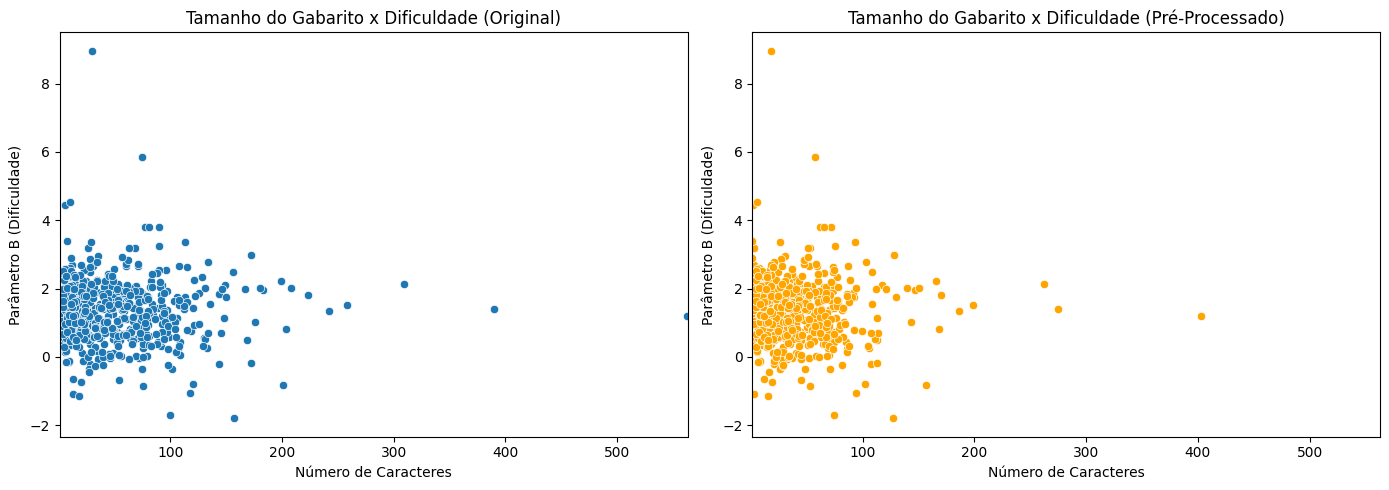

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de dispersão do tamanho dos enunciados
sns.scatterplot(x=tamanho_gabarito, y=enem_df["dificuldade"], ax=axes[0])
axes[0].set_title("Tamanho do Gabarito x Dificuldade (Original)")
axes[0].set_ylabel("Parâmetro B (Dificuldade)")
axes[0].set_xlabel("Número de Caracteres")

# Gráfico de dispersão do tamanho dos enunciados pré-processados
sns.scatterplot(
    x=tamanho_gabarito_tokens, y=enem_df["dificuldade"], ax=axes[1], color="orange"
)
axes[1].set_title("Tamanho do Gabarito x Dificuldade (Pré-Processado)")
axes[1].set_ylabel("Parâmetro B (Dificuldade)")
axes[1].set_xlabel("Número de Caracteres")

x_min = tamanho_gabarito_tokens.min()
x_max = tamanho_gabarito.max()
axes[0].set_xlim(x_min, x_max)
axes[1].set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

### 4.4.4. Distribuição dos Distratores (Alternativas Incorretas)


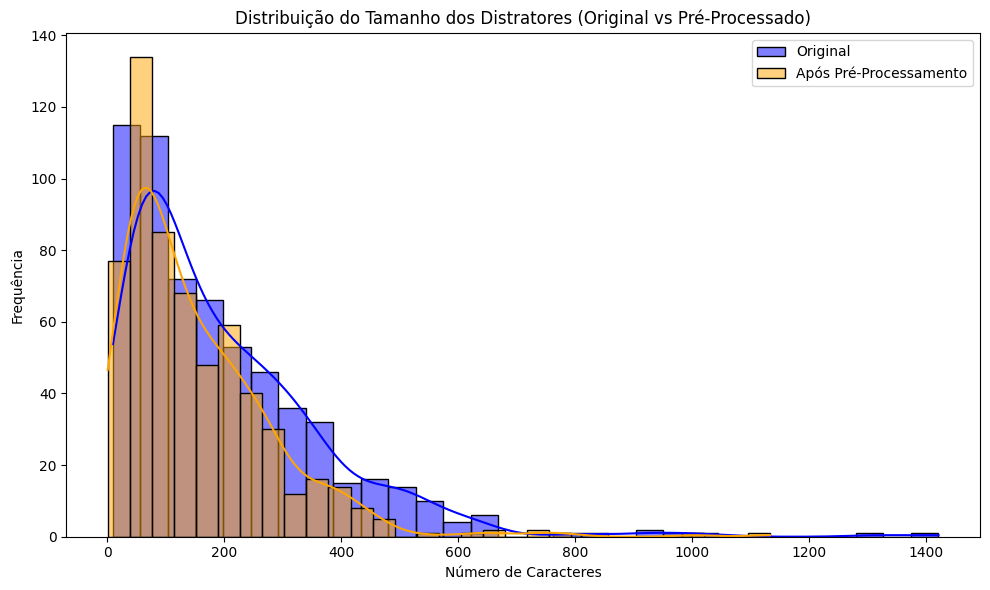

In [35]:
plt.figure(figsize=(10, 6))

# Coletando tamanho dos distratores
tamanho_distratores = enem_df["distratores"].str.len()
tamanho_distratores_tokens = enem_df["distratores_tokens"].str.len()

# Histograma dos distratores originais
sns.histplot(
    tamanho_distratores, bins=30, kde=True, color="blue", label="Original", alpha=0.5
)

# Histograma dos distratores pré-processados
sns.histplot(
    tamanho_distratores_tokens,
    bins=30,
    kde=True,
    color="orange",
    label="Após Pré-Processamento",
    alpha=0.5,
)

plt.title("Distribuição do Tamanho dos Distratores (Original vs Pré-Processado)")
plt.xlabel("Número de Caracteres")
plt.ylabel("Frequência")
plt.legend()
plt.tight_layout()
plt.show()

### 4.4.5. Gráfico de Dispersão (Distratores x Dificuldade)


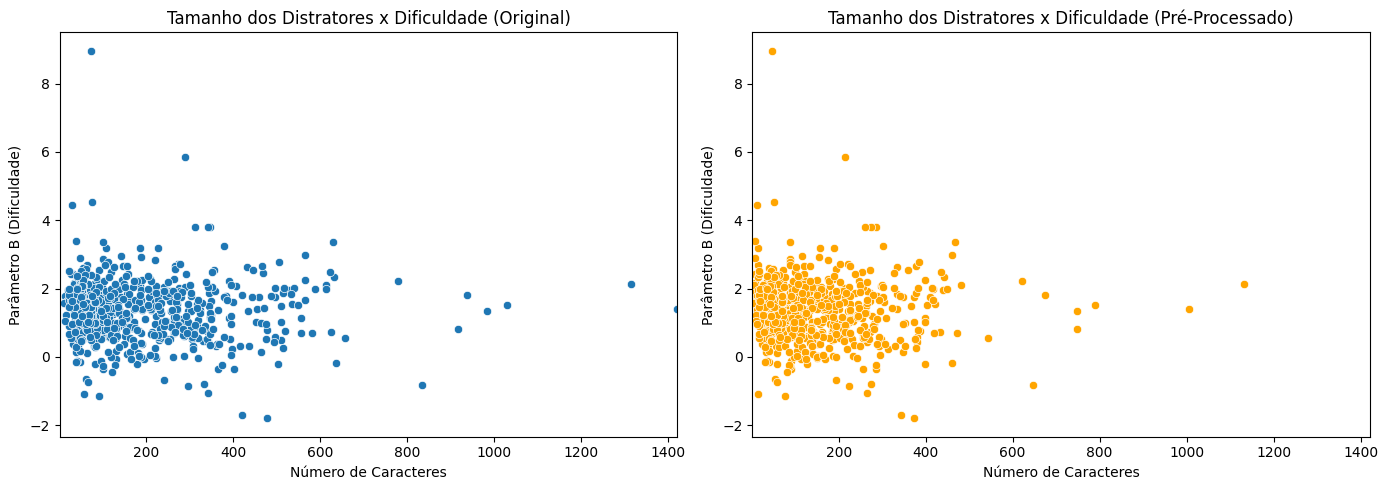

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de dispersão do tamanho dos distratores
sns.scatterplot(x=tamanho_distratores, y=enem_df["dificuldade"], ax=axes[0])
axes[0].set_title("Tamanho dos Distratores x Dificuldade (Original)")
axes[0].set_ylabel("Parâmetro B (Dificuldade)")
axes[0].set_xlabel("Número de Caracteres")

# Gráfico de dispersão do tamanho dos distratores pré-processados
sns.scatterplot(
    x=tamanho_distratores_tokens, y=enem_df["dificuldade"], ax=axes[1], color="orange"
)
axes[1].set_title("Tamanho dos Distratores x Dificuldade (Pré-Processado)")
axes[1].set_ylabel("Parâmetro B (Dificuldade)")
axes[1].set_xlabel("Número de Caracteres")

x_min = tamanho_distratores_tokens.min()
x_max = tamanho_distratores.max()
axes[0].set_xlim(x_min, x_max)
axes[1].set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

---

## 4.5. Nuvem de Palavras


### 4.5.1. Funções Auxiliares

In [37]:
# Função auxiliar para gerar nuvens de palavras
def generate_wordcloud(df, col):
    # 1. Filtrar os dados
    df_counter = df.dropna(subset=[col])  # Remove NaN
    median_dif = df_counter["dificuldade"].median()

    # 2. Textos para cada grupo
    text_total = " ".join(df_counter[col])
    text_hard = " ".join(df_counter[df_counter["dificuldade"] > median_dif][col])
    text_easy = " ".join(df_counter[df_counter["dificuldade"] <= median_dif][col])

    # 3. Configurar as nuvens
    wordcloud_total = WordCloud(
        width=600, height=300, background_color="white"
    ).generate(text_total)
    wordcloud_hard = WordCloud(
        width=600, height=300, background_color="white"
    ).generate(text_hard)
    wordcloud_easy = WordCloud(
        width=600, height=300, background_color="white"
    ).generate(text_easy)

    # 4. Plotar em uma linha
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Nuvem 1: Total
    axes[0].imshow(wordcloud_total, interpolation="bilinear")
    axes[0].set_title("Todos os Enunciados", fontsize=12)
    axes[0].axis("off")

    # Nuvem 2: Maior dificuldade
    axes[1].imshow(wordcloud_hard, interpolation="bilinear")
    axes[1].set_title(f"Maior Dificuldade ( > {median_dif:.2f})", fontsize=12)
    axes[1].axis("off")

    # Nuvem 3: Menor dificuldade
    axes[2].imshow(wordcloud_easy, interpolation="bilinear")
    axes[2].set_title(f"Menor Dificuldade ( ≤ {median_dif:.2f})", fontsize=12)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

In [38]:
# Função auxiliar para gerar frequência de palavras
def generate_word_frequencies(df, col, top_n=10):
    # 1. Filtrar os dados
    df_counter = df.dropna(subset=[col])
    median_dif = df_counter["dificuldade"].median()

    # 2. Definir os grupos
    text_total = df_counter[col]
    text_hard = df_counter[df_counter["dificuldade"] > median_dif][col]
    text_easy = df_counter[df_counter["dificuldade"] <= median_dif][col]

    # 3. Contar palavras (top 10 em cada grupo)
    def get_top_words(text_series, n=top_n):
        vectorizer = CountVectorizer()
        X = vectorizer.fit_transform(text_series)
        word_counts = pd.DataFrame(
            X.toarray(), columns=vectorizer.get_feature_names_out()
        ).sum()
        return word_counts.sort_values(ascending=False).head(n)

    top_total = get_top_words(text_total)
    top_hard = get_top_words(text_hard)
    top_easy = get_top_words(text_easy)

    # 4. Plotar histogramas lado a lado
    fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

    # Histograma 1: Total
    axes[0].barh(top_total.index, top_total.values, color="skyblue")
    axes[0].set_title("Todos os Enunciados")
    axes[0].invert_yaxis()

    # Histograma 2: Alta dificuldade
    axes[1].barh(top_hard.index, top_hard.values, color="salmon")
    axes[1].set_title(f"Maior Dificuldade ( > {median_dif:.2f})")

    # Histograma 3: Baixa dificuldade
    axes[2].barh(top_easy.index, top_easy.values, color="lightgreen")
    axes[2].set_title(f"Menor Dificuldade ( ≤ {median_dif:.2f})")

    plt.tight_layout()
    plt.show()

### 4.5.2. Enunciado

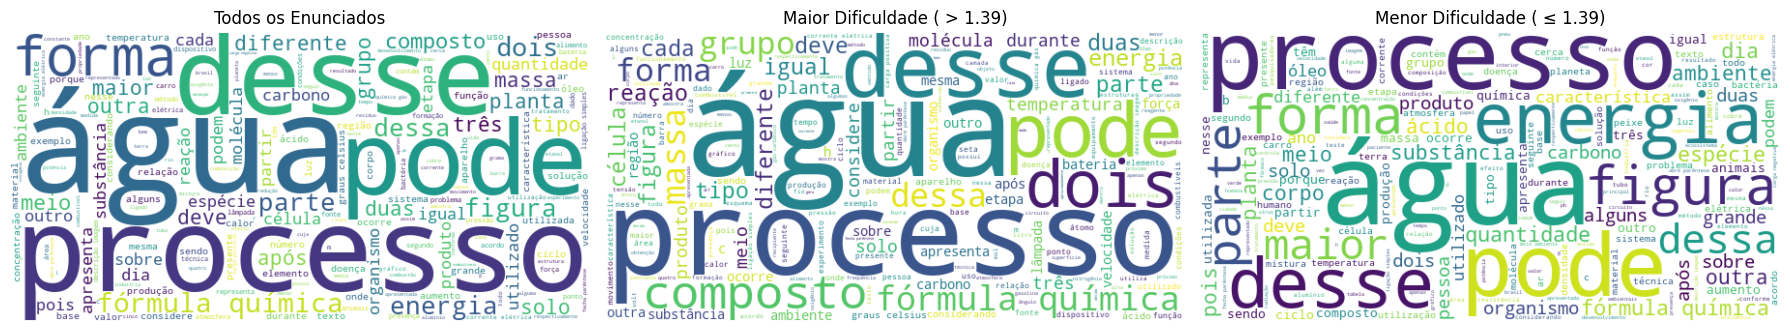

In [39]:
generate_wordcloud(enem_df, "enunciado_tokens")

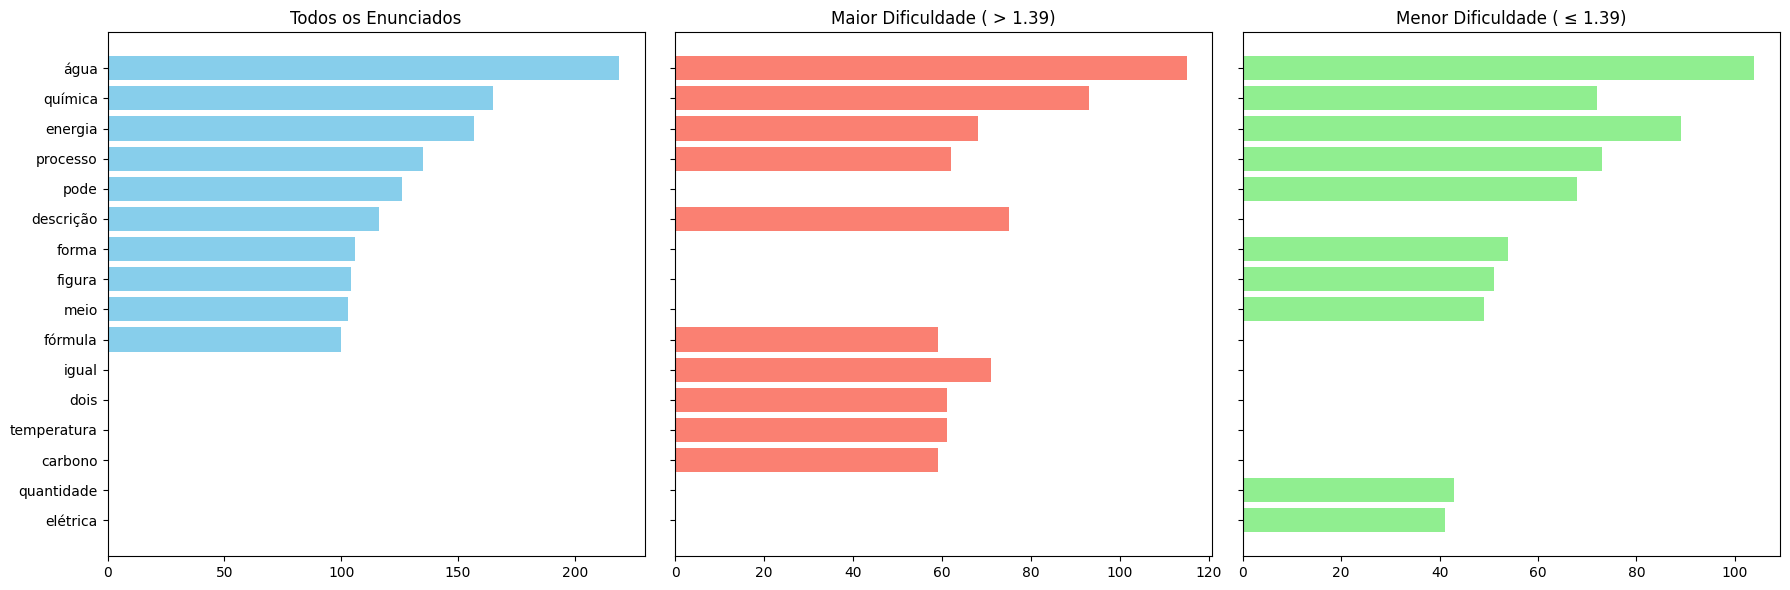

In [40]:
generate_word_frequencies(enem_df, "enunciado_tokens")

### 4.5.3. Gabarito

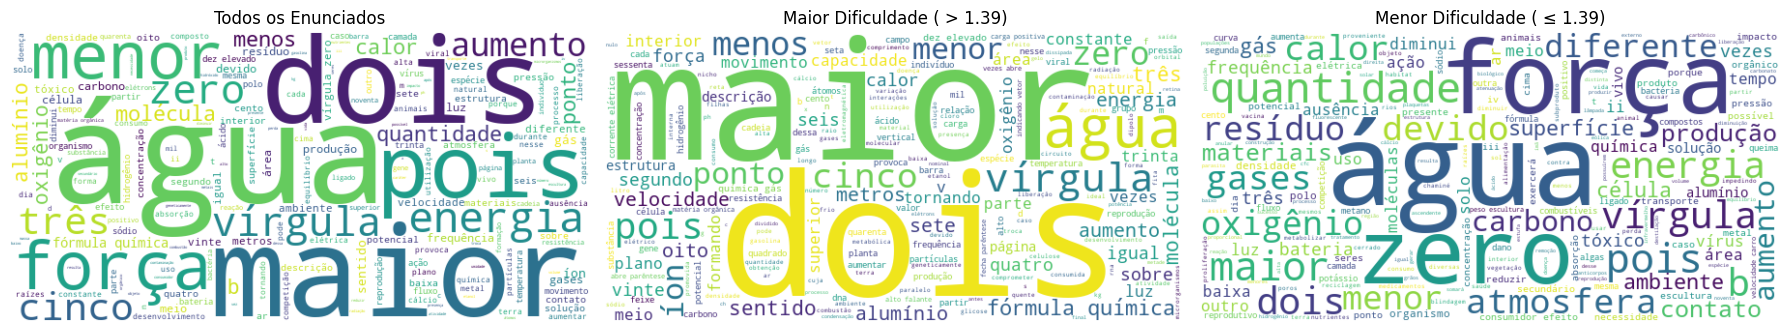

In [41]:
generate_wordcloud(enem_df, "gabarito_tokens")

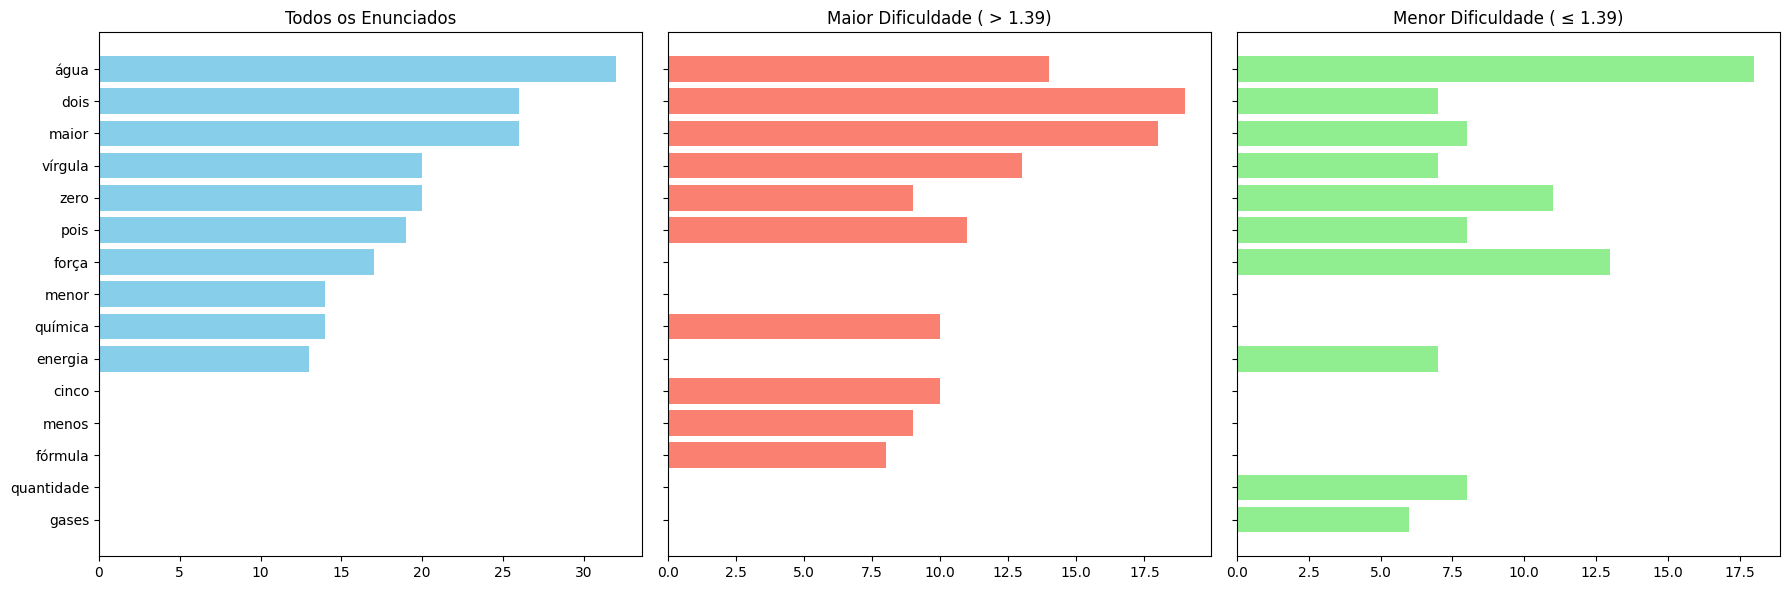

In [42]:
generate_word_frequencies(enem_df, "gabarito_tokens")

### 4.5.4. Distratores

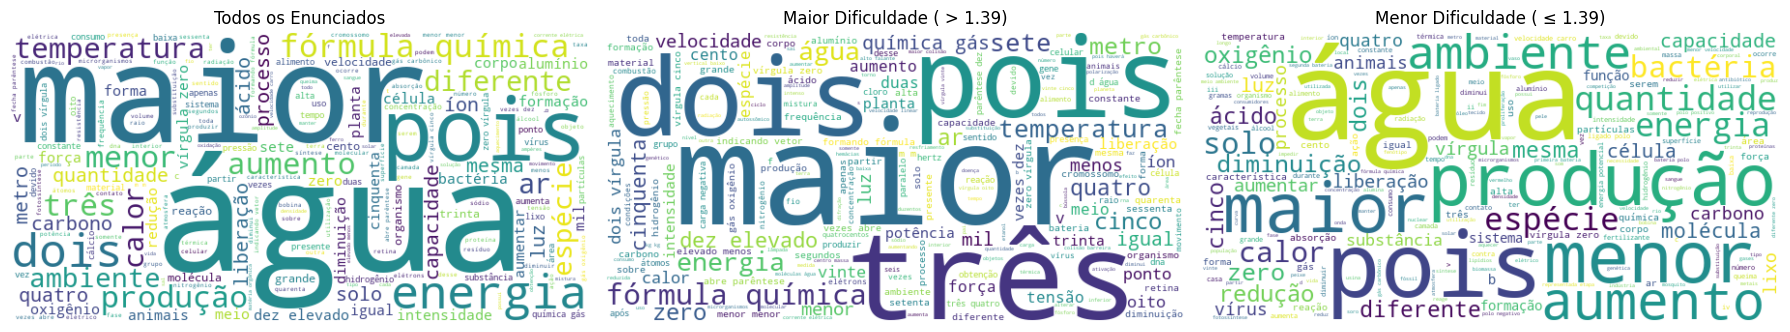

In [43]:
generate_wordcloud(enem_df, "distratores_tokens")

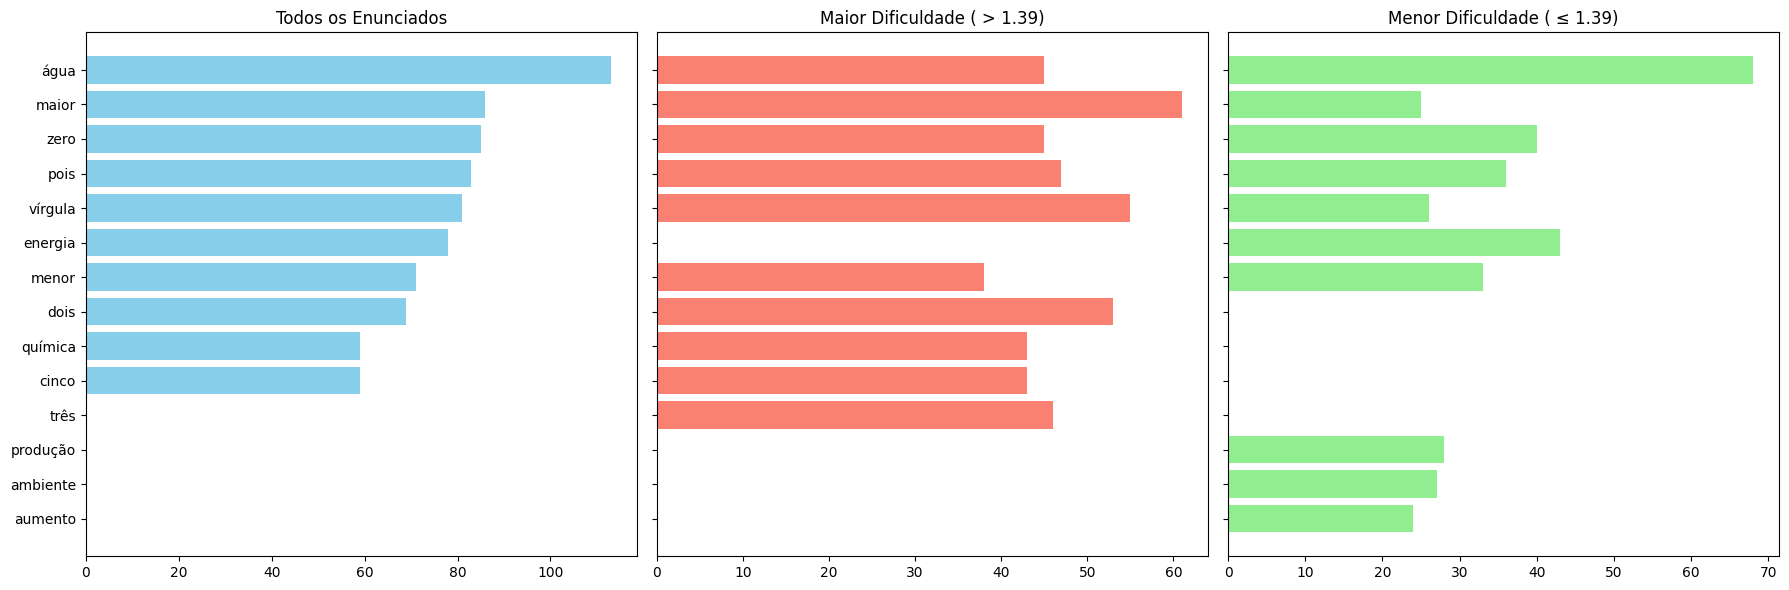

In [44]:
generate_word_frequencies(enem_df, "distratores_tokens")

---